In [1]:
import json
import numpy as np
import tensorflow as tf
from random import random
from pathlib import Path
import ray
from ray.rllib.policy.policy import Policy
from ray.rllib.algorithms.algorithm import Algorithm
from ray.rllib.examples.env.AmelioratingInventoryPOM import AmelioratingInventoryEnv as env
import ray.rllib.algorithms.apo as apo
from ray.tune.registry import register_env, register_trainable
from ray.rllib.utils.checkpoints import get_checkpoint_info
import scipy.stats as st
import os
import matplotlib.pyplot as plt



c:\Users\ga84cib\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
#create sampling data for common random numbers

# Configuration
corr_values = [0.3, 0.9]
n_samples_per_batch = 1000
n_batches = 50
n_warm_up = 1000
total_samples = n_samples_per_batch * n_batches + n_warm_up

# Seed for reproducibility
np.random.seed(3031993)

# Generate base common random numbers (uncorrelated standard normal)
base_samples = np.random.normal(size=(total_samples, 3))

# Store aligned data
data = {}

for corr in corr_values:
    # Define the covariance matrix
    cov_matrix = [[1.0, corr, corr], [corr, 1.0, 0.95], [corr, 0.95, 1.0]]
    
    # Perform Cholesky decomposition
    cholesky_decomp = np.linalg.cholesky(cov_matrix)
    
    # Transform base samples to have the desired correlation
    correlated_samples = base_samples @ cholesky_decomp.T
    
    # Store the samples
    data[corr] = correlated_samples.tolist()

# Save the aligned data to a JSON file
with open("cheese/evaluation_data_aligned_x.json", "w") as f:
    json.dump(data, f)


In [23]:
#time analysis for different architectures
def time_analysis():
    #load the time data
    time_data = {}
    with open("cheese/cheese_010/training_results/time_per_iteration.json", "r") as f:
        time_data["$SI$"] = json.load(f)
    with open("cheese/cheese_010/training_results/time_per_iteration_0.json", "r") as f:
        time_data["$S0$"] = json.load(f)
    with open("cheese/cheese_010/training_results/time_per_iteration_1.json", "r") as f:
        time_data["$S1$"] = json.load(f)
    with open("cheese/cheese_010/training_results/time_per_iteration_py.json", "r") as f:
        time_data["$SH$"] = json.load(f)
    with open("cheese/cheese_010_group/training_results/time_per_iteration.json", "r") as f:
        time_data["$MG$"] = json.load(f)
    with open("cheese/cheese_010_production/training_results/time_per_iteration.json", "r") as f:
        time_data["$MH$"] = json.load(f)
    with open("cheese/cheese_010_1perAgent/training_results/time_per_iteration.json", "r") as f:
        time_data["$MA$"] = json.load(f)
    return time_data
time_data = time_analysis()
# print the mean time data in relation to $SI$
mean_time_data = {}
for key, value in time_data.items():
    mean_time_data[key] = np.mean(value) / np.mean(time_data["$SI$"])
    print(f"{key}: {mean_time_data[key]:.2f}x")

    

$SI$: 1.00x
$S0$: 0.81x
$S1$: 0.83x
$SH$: 0.85x
$MG$: 2.12x
$MH$: 2.18x
$MA$: 4.54x


In [ ]:

architectures = ["$SI$", "$S0$", "$S1$", "$SH$", "$MA$", "$MG$", "$MH$", "$LP$", "$NC$"]


In [2]:
problem_ids = ["cheese_010", "cheese_020", "cheese_012", "cheese_022", "cheese_110", "cheese_120", "cheese_112", "cheese_122", "cheese_210", "cheese_220", "cheese_212", "cheese_222", "cheese_310", "cheese_320", "cheese_312", "cheese_322"] #, "cheese_012_production", "cheese_022_production", "cheese_110_production", "cheese_120_production", "cheese_112_production", "cheese_122_production", "cheese_210_production", "cheese_220_production", "cheese_212_production", "cheese_222_production"] # "cheese_210", "cheese_220", "cheese_110", "cheese_120", "cheese_310", "cheese_320", "cheese_112", "cheese_122", "cheese_212", "cheese_222", "cheese_112", "cheese_122", "cheese_312", "cheese_322"]
architectures = ["$SI$", "$S0$", "$S1$", "$SH$", "$MA$", "$MG$", "$MH$", "$LP$", "$NC$"]

architecture_paths = {
    "$SI$": {pid: f"cheese/{pid}/training_results/full_blending_full_nn_none_lp_100w/regression_data_crn.json" for pid in problem_ids},
    "$S0$": {pid: f"cheese/{pid}/training_results/0_blending_full_nn_none_lp_100w/regression_data_crn.json" for pid in problem_ids},
    "$S1$": {pid: f"cheese/{pid}/training_results/1_blending_full_nn_none_lp_100w/regression_data_crn.json" for pid in problem_ids},
    "$SH$": {pid: f"cheese/{pid}/training_results/full_blending_py_nn_x_lp_100w/regression_data_crn.json" for pid in problem_ids},
    "$MA$": {pid: f"cheese/{pid}_1perAgent/training_results/full_blending_full_nn_none_lp_100w/regression_data_crn.json" for pid in problem_ids[:4]},
    "$MG$": {pid: f"cheese/{pid}_group/training_results/full_blending_full_nn_none_lp_100w/regression_data_crn.json" for pid in problem_ids},
    "$MH$": {pid: f"cheese/{pid}_production/training_results/full_blending_full_nn_none_lp_100w/regression_data_crn.json" for pid in problem_ids},
    "$LP$": {pid: f"cheese/{pid}/training_results/full_blending_full_nn_none_lp_100w/regression_data_crn_heuristic.json" for pid in problem_ids},
    "$NC$": {pid: f"cheese/{pid}/regression_data_crn_nocorrel.json" for pid in problem_ids}
}

#load regression_data
data = {}
for pid in problem_ids:
    data[pid] = {}
    for arch, path in architecture_paths.items():
        if pid not in path:
            continue
        print(f"Loading data for {pid} with architecture {arch}")
        with open(path[pid], "r") as f:
            res = json.load(f)
        data[pid][arch] = {(k): v for k,v in res.items()}
    
# #load performance of LP
# lp_data = {}
# for pid in problem_ids:
#     print(pid)
#     with open(f"cheese/{pid}/training_results/full_blending_full_nn_none_lp_100w/regression_data_crn_heuristic.json", "r") as f:
#         res = json.load(f)
#     lp_data[pid] = {(k): v for k,v in res.items()}

    

Loading data for cheese_010 with architecture $SI$
Loading data for cheese_010 with architecture $S0$
Loading data for cheese_010 with architecture $S1$
Loading data for cheese_010 with architecture $SH$
Loading data for cheese_010 with architecture $MA$
Loading data for cheese_010 with architecture $MG$
Loading data for cheese_010 with architecture $MH$
Loading data for cheese_010 with architecture $LP$
Loading data for cheese_010 with architecture $NC$
Loading data for cheese_020 with architecture $SI$
Loading data for cheese_020 with architecture $S0$
Loading data for cheese_020 with architecture $S1$
Loading data for cheese_020 with architecture $SH$
Loading data for cheese_020 with architecture $MA$
Loading data for cheese_020 with architecture $MG$
Loading data for cheese_020 with architecture $MH$
Loading data for cheese_020 with architecture $LP$
Loading data for cheese_020 with architecture $NC$
Loading data for cheese_012 with architecture $SI$
Loading data for cheese_012 wit

In [3]:
#relate pids to factor levels
factors = ["speed", "volatility_purchase", "volatility_sales", "correlation"]

factor_symbols = {"speed": "$\\theta$", "correlation": "$\\rho$", "volatility_purchase": "$\sigma^{\psi}$", "volatility_sales": "$\sigma^{\phi}$"}

markers = {"speed": "o", "correlation": "s", "volatility_purchase": "v", "volatility_sales": "^"}

colors = {"speed": "blue", "correlation": "red", "volatility_purchase": "green", "volatility_sales": "purple"}


factors_pid = {f: {} for f in factors}

print(problem_ids)
for pid in problem_ids:
    if pid[7] == "0":
        factors_pid["volatility_purchase"][pid] = 0
        factors_pid["volatility_sales"][pid] = 0
    elif pid[7] == "1":
        factors_pid["volatility_purchase"][pid] = 1
        factors_pid["volatility_sales"][pid] = 0
    elif pid[7] == "2":
        factors_pid["volatility_purchase"][pid] = 0
        factors_pid["volatility_sales"][pid] = 1
    elif pid[7] == "3":
        factors_pid["volatility_purchase"][pid] = 1
        factors_pid["volatility_sales"][pid] = 1
    
    if pid[8] == "1":
        factors_pid["correlation"][pid] = 0
    elif pid[8] == "2":
        factors_pid["correlation"][pid] = 1
    
    if pid[9] == "0":
        factors_pid["speed"][pid] = 0
    elif pid[9] == "2":
        factors_pid["speed"][pid] = 1

print(factors_pid)
    

['cheese_010', 'cheese_020', 'cheese_012', 'cheese_022', 'cheese_110', 'cheese_120', 'cheese_112', 'cheese_122', 'cheese_210', 'cheese_220', 'cheese_212', 'cheese_222', 'cheese_310', 'cheese_320', 'cheese_312', 'cheese_322']
{'speed': {'cheese_010': 0, 'cheese_020': 0, 'cheese_012': 1, 'cheese_022': 1, 'cheese_110': 0, 'cheese_120': 0, 'cheese_112': 1, 'cheese_122': 1, 'cheese_210': 0, 'cheese_220': 0, 'cheese_212': 1, 'cheese_222': 1, 'cheese_310': 0, 'cheese_320': 0, 'cheese_312': 1, 'cheese_322': 1}, 'volatility_purchase': {'cheese_010': 0, 'cheese_020': 0, 'cheese_012': 0, 'cheese_022': 0, 'cheese_110': 1, 'cheese_120': 1, 'cheese_112': 1, 'cheese_122': 1, 'cheese_210': 0, 'cheese_220': 0, 'cheese_212': 0, 'cheese_222': 0, 'cheese_310': 1, 'cheese_320': 1, 'cheese_312': 1, 'cheese_322': 1}, 'volatility_sales': {'cheese_010': 0, 'cheese_020': 0, 'cheese_012': 0, 'cheese_022': 0, 'cheese_110': 0, 'cheese_120': 0, 'cheese_112': 0, 'cheese_122': 0, 'cheese_210': 1, 'cheese_220': 1, 'ch

In [4]:
#compare the average reward of two architectures
def compare_architectures(arch1, arch2):
    rewards = {}
    for pid in problem_ids:
        if arch1 not in data[pid] or arch2 not in data[pid]:
            continue
        rewards[pid] = np.mean(normalized_rewards[pid][arch1]) / np.mean(normalized_rewards[pid][arch2])
        #test significance

    # Perform a t-test to check if the difference is significant
    reward_differences = np.array([np.mean(normalized_rewards[pid][arch1]) - np.mean(normalized_rewards[pid][arch2]) for pid in rewards.keys()])
    t_statistic, p_value = st.ttest_1samp(reward_differences, 0)
    return np.mean(list(rewards.values())), p_value

print("Average reward of $S1$ compared to $SI$:", compare_architectures("$S1$", "$SI$"))



NameError: name 'normalized_rewards' is not defined

{'cheese_010': '$S0$', 'cheese_020': '$S0$', 'cheese_012': '$MH$', 'cheese_022': '$SH$', 'cheese_110': '$S0$', 'cheese_120': '$S0$', 'cheese_112': '$MH$', 'cheese_122': '$MH$', 'cheese_210': '$S0$', 'cheese_220': '$S0$', 'cheese_212': '$SH$', 'cheese_222': '$SH$', 'cheese_310': '$SH$', 'cheese_320': '$S0$', 'cheese_312': '$MH$', 'cheese_322': '$MH$'}
{'$SI$': 0.0213002529473638, '$S0$': 0.009037646178689747, '$S1$': 0.008563766523372702, '$SH$': 0.002734067217386964, '$MA$': 0.007824161435388178, '$MG$': 0.012077768965234461, '$MH$': 0.004516939930898171, '$LP$': 0.16733405427888975, '$NC$': 0.06749398928056496}
(0.008878888397172801, 'cheese_210')
{'$SI$': {'speed': {'+': 0.011471343085260058, '-': 0.031129162809467543}, 'volatility_purchase': {'+': 0.024796109858501135, '-': 0.017804396036226466}, 'volatility_sales': {'+': 0.019212722801217143, '-': 0.02338778309351046}, 'correlation': {'+': 0.019156405844118582, '-': 0.02344410005060902}}, '$S0$': {'speed': {'+': 0.01789362155069966

c:\Users\ga84cib\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\ga84cib\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


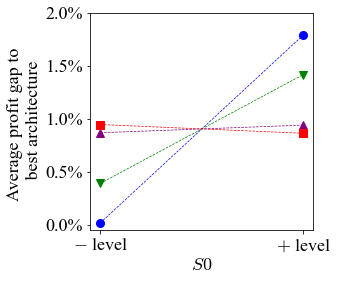

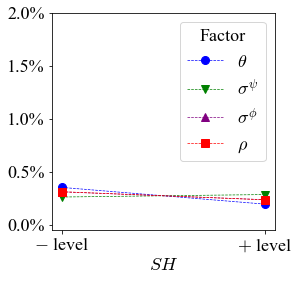

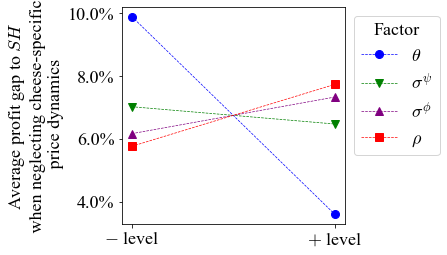

Largest percentage increase from allowing issuance flexibility: (0.03048527944041634, 'cheese_312')
Average percentage increase from allowing issuance flexibility: 0.009254972547147848
dict_keys(['$SI$', '$S0$', '$S1$', '$SH$', '$MG$', '$MH$', '$LP$', '$NC$', 'upper_bound'])
1378.1857090722824


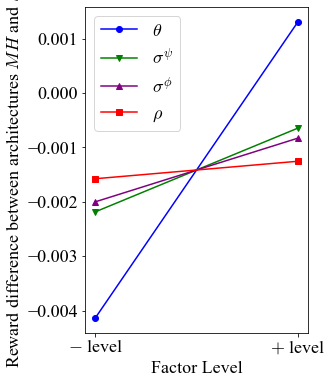

In [7]:
# get the average performance of each architecture measured by the gap to the best architecture averaged over all problem instances

#first get the best architecture for each problem instance
def get_best_architecture(data):
    best_architecture = {}
    for pid in problem_ids:
        best_architecture[pid] = None
        best_performance = -np.inf
        for arch in architectures:
            if arch not in data[pid]:
                continue
            rewards = normalized_rewards[pid][arch]
            if np.mean(rewards) > best_performance:
                best_performance = np.mean(rewards)
                best_architecture[pid] = arch
    return best_architecture

best_architecture = get_best_architecture(data)
print(best_architecture)
# get the average performance of each architecture measured by the percentage gap to the best architecture averaged over all problem instan

def get_gap_performance(data, best_architecture):  
    average_performance = {}
    for arch in architectures:
        average_performance[arch] = []
        for pid in problem_ids:
            if arch not in data[pid]:
                continue
            rewards = normalized_rewards[pid][arch]
            best_rewards = normalized_rewards[pid][best_architecture[pid]]
            gap = (np.mean(best_rewards) - np.mean(rewards)) / np.mean(best_rewards)
            average_performance[arch].append(gap)
    return average_performance
average_performance = get_gap_performance(data, best_architecture)
print({arch: np.mean(average_performance[arch]) for arch in architectures})

#show largest gap to best architecture
def get_largest_gap(data, architecture):
    largest_gap = (0, None)
    for pid in problem_ids:
        if architecture not in data[pid]:
            continue
        rewards = normalized_rewards[pid][architecture]
        best_rewards = normalized_rewards[pid][best_architecture[pid]]
        gap = (np.mean(best_rewards) - np.mean(rewards)) / np.mean(best_rewards)
        if gap > largest_gap[0]:
            largest_gap = gap, pid
    return largest_gap
largest_gap = get_largest_gap(data, "$SH$")
print(largest_gap)

#analyze the performance of each architecture for each factor level - and +
def get_factor_performance(data, best_architecture, factors_pid):
    factor_performance = {arch: {f: {"-": [], "+": []} for f in factors} for arch in architectures}
    for arch in architectures:
        for pid in problem_ids:
            if arch not in data[pid]:
                continue
            rewards = normalized_rewards[pid][arch]
            best_rewards = normalized_rewards[pid][best_architecture[pid]]
            gap = (np.mean(best_rewards) - np.mean(rewards)) / np.mean(best_rewards)
            
            for f in factors:
                if factors_pid[f][pid] == 0:
                    factor_performance[arch][f]["-"].append(gap)
                else:
                    factor_performance[arch][f]["+"].append(gap)
    return factor_performance

factor_performance = get_factor_performance(data, best_architecture, factors_pid)
print({arch: {f: {"+": np.mean(factor_performance[arch][f]["+"]), "-": np.mean(factor_performance[arch][f]["-"])} for f in factors} for arch in architectures})

#change font style and size and math font
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams.update({'font.size': 18})
plt.rcParams['mathtext.fontset'] = 'cm' 

#create one single line plot without subplots showing the main effects for different factors between their - and + levels (- and + should be the x-axis labels)
def plot_factor_performance(factor_performance, factors, architecture, fixed_ylim=True, ytitle=True, legend=False, legend_outside=False):
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.set_xticks([0, 1], ["$-$ level", "$+$ level"])
    if fixed_ylim:
        ax.set_yticks([0.0, 0.005, 0.01, 0.015, 0.02])
        ax.set_ylim(-0.0005, 0.02)
    if architecture != "$NC$":
        ax.set_xlabel(architecture)
    if ytitle:
        if architecture == "$NC$":
            ax.set_ylabel("Average profit gap to $SH$ \n when neglecting cheese-specific \n price dynamics")
        else:
            ax.set_ylabel("Average profit gap to \n best architecture")
    
    markers = {"speed": "o", "correlation": "s", "volatility_purchase": "v", "volatility_sales": "^"}
    colors = {"speed": "blue", "correlation": "red", "volatility_purchase": "green", "volatility_sales": "purple"}

    #multiply y ticks by 100 and add percentage sign and show one decimal place
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.1f}%'))

    for f in factors:
        minus = factor_performance[architecture][f]["-"]
        plus = factor_performance[architecture][f]["+"]
        ax.plot([0, 1], [np.mean(minus), np.mean(plus)], marker=markers[f], color=colors[f], label=factor_symbols[f], linestyle='--', linewidth=0.7, markersize=8)
    if legend:
        ax.legend(title="Factor")
    if legend_outside:
        ax.legend(title="Factor", loc='upper left', bbox_to_anchor=(1, 1), frameon=True)
    plt.savefig(f"figures/factor_performance_{architecture}.pdf", bbox_inches='tight', pad_inches=0.1)

    plt.show() 
plot_factor_performance(factor_performance, factors, "$S0$")
plot_factor_performance(factor_performance, factors, "$SH$", ytitle=False, legend=True)

plot_factor_performance(factor_performance, factors, "$NC$", fixed_ylim=False, ytitle=True, legend=True, legend_outside=True)

#calculate largest percentage profit increase from allowing issuance flexibility (all architectures vs $S0$)
def get_largest_percentage_increase(data):
    largest_increase = (0, None)
    for pid in problem_ids:
        rewards = normalized_rewards[pid][best_architecture[pid]]
        zero_rewards = normalized_rewards[pid]["$S0$"]
        increase = (np.mean(rewards) - np.mean(zero_rewards)) / np.mean(zero_rewards)
        if increase > largest_increase[0]:
            largest_increase = increase, pid
    return largest_increase

def get_average_percentage_increase(data):
    largest_increase = (0, None)
    total_increase = 0
    for pid in problem_ids:
        rewards = normalized_rewards[pid][best_architecture[pid]]
        zero_rewards = normalized_rewards[pid]["$S0$"]
        increase = (np.mean(rewards) - np.mean(zero_rewards)) / np.mean(zero_rewards)
        total_increase += increase
    return total_increase / len(problem_ids)

largest_increase = get_largest_percentage_increase(data)
print("Largest percentage increase from allowing issuance flexibility:", largest_increase)

print("Average percentage increase from allowing issuance flexibility:", get_average_percentage_increase(data))

print(data[pid].keys())
print(data[pid]["upper_bound"])
norm_perc_rewards = {pid: {arch: np.mean(normalized_rewards[pid][arch])/data[pid]['upper_bound'] for arch in architectures if arch in data[pid]} for pid in problem_ids}
    

#compare two architectures for each factor level based on normalized percentage rewards
def plot_architecture_performance(factor_performance, factors, architecture1, architecture2):
    fig, ax = plt.subplots(figsize=(4, 6))
    ax.set_xticks([0, 1], ["$-$ level", "$+$ level"])
    ax.set_xlabel("Factor Level")
    ax.set_ylabel(f"Reward difference between architectures {architecture1} and {architecture2}") 
    
    markers = {"speed": "o", "correlation": "s", "volatility_purchase": "v", "volatility_sales": "^"}
    colors = {"speed": "blue", "correlation": "red", "volatility_purchase": "green", "volatility_sales": "purple"}
    factor_symbols = {"speed": "$\\theta$", "correlation": "$\\rho$", "volatility_purchase": "$\sigma^{\psi}$", "volatility_sales": "$\sigma^{\phi}$"}
        
    diff_performance = {}
    for pid in problem_ids:
        if architecture1 not in data[pid] or architecture2 not in data[pid]:
            continue
        diff_performance[pid] = np.mean(norm_perc_rewards[pid][architecture1]) - np.mean(norm_perc_rewards[pid][architecture2])
    
    for f in factors:
        minus = [diff_performance[pid] for pid in factors_pid[f] if factors_pid[f][pid] == 0 and pid in diff_performance]
        plus = [diff_performance[pid] for pid in factors_pid[f] if factors_pid[f][pid] == 1 and pid in diff_performance]
        ax.plot([0, 1], [np.mean(minus), np.mean(plus)], marker=markers[f], color=colors[f], label=factor_symbols[f])


        
    ax.legend()
    
    plt.show()
plot_architecture_performance(factor_performance, factors, "$MH$", "$SH$")



   

In [5]:
#get average reward for each problem assuming that data is stored in the variable with the name of the problem id

# for pid in problem_ids:
#     print(pid)
#     rewards = []
#     rewards.append(data[pid]["rewards"])
#     print(np.mean(rewards))

pids_norm = {pid: pid.split("_")[0]+"_"+pid.split("_")[1] for pid in problem_ids}

#get upper bound on average rewards from problem config file
for pid in problem_ids:
    print(pid)
    with open(f"cheese/{pids_norm[pid]}/upper_bound.json", "r") as f:
        res = json.load(f)
    data[pid]["upper_bound"] = res["upper_bound"]
    print(data[pid]["upper_bound"])
    


#denormalize rewards using upper bounds for each problem
normalized_rewards = {}
normalized_lp_rewards = {}
for pid in problem_ids:
    print(pid)
    normalized_rewards[pid] = {}
    for arch in architectures:
        if arch not in data[pid]:
            continue
        print(arch)
        rewards = []
        rewards.append(data[pid][arch]["rewards"])
        normalized_rewards[pid][arch] = ((np.array(rewards)+1)/2)*data[pid]["upper_bound"]
        print(np.mean(normalized_rewards[pid][arch]))
        print("relative to upper bound: ", np.mean(normalized_rewards[pid][arch])/data[pid]["upper_bound"])
    

cheese_010
1253.400429061677
cheese_020
1253.4000615811697
cheese_012
1253.400074674573
cheese_022
1253.400074674573
cheese_110
1364.409851432042
cheese_120
1364.409851432042
cheese_112
1364.409725735138
cheese_122
1385.5302834218026
cheese_210
1266.0353148771976
cheese_220
1266.0353148771976
cheese_212
1266.0352650441523
cheese_222
1266.0352650441523
cheese_310
1378.1856698351583
cheese_320
1378.1856698351583
cheese_312
1378.1857090722824
cheese_322
1378.1857090722824
cheese_010
$SI$
1000.0951131419246
relative to upper bound:  0.7979055136359078
$S0$
1028.7668273976574
relative to upper bound:  0.8207806567992121
$S1$
1021.4188907718501
relative to upper bound:  0.8149182552430644
$SH$
1024.4314938823175
relative to upper bound:  0.8173217992666791
$MA$
1018.0350053986089
relative to upper bound:  0.8122184912292811
$MG$
1011.2393332854322
relative to upper bound:  0.8067967026646609
$MH$
1014.9356564730919
relative to upper bound:  0.80974573882418
$LP$
982.8226352765912
relative to

In [46]:
#also get denormalized rewards for the problems without autoregressive prices
problem_ids_no_ar = ["cheese_013", "cheese_123", "cheese_223"]

for pid in problem_ids_no_ar:
    print(pid)
    with open(f"cheese/{pid}/training_results/full_blending_full_nn_none_lp_100w/regression_data.json", "r") as f:
        res = json.load(f)
    data[pid] = {(k): v for k,v in res.items()}

    with open(f"cheese/{pid}/config.json", "r") as f:
        res = json.load(f)
    data[pid]["upper_bound"] = res["upper_bound"]["max_reward"]
    rewards = []
    rewards.append(data[pid]["rewards"])
    data[pid]["normalized_rewards"] = np.array(rewards)*data[pid]["upper_bound"]
    print(np.mean(data[pid]["normalized_rewards"]))

cheese_013
954.0836503497982
cheese_123
1042.2495078258783
cheese_223
965.4579970250684


Problem instance with maximum average reward: cheese_112 with 1080.8401460181158 of maximum average reward
['cheese_010', 'cheese_020', 'cheese_012', 'cheese_022', 'cheese_110', 'cheese_120', 'cheese_112', 'cheese_122', 'cheese_210', 'cheese_220', 'cheese_212', 'cheese_222', 'cheese_310', 'cheese_320', 'cheese_312', 'cheese_322']
{'speed': {'cheese_010': 0, 'cheese_020': 0, 'cheese_012': 1, 'cheese_022': 1, 'cheese_110': 0, 'cheese_120': 0, 'cheese_112': 1, 'cheese_122': 1, 'cheese_210': 0, 'cheese_220': 0, 'cheese_212': 1, 'cheese_222': 1, 'cheese_310': 0, 'cheese_320': 0, 'cheese_312': 1, 'cheese_322': 1}, 'volatility_purchase': {'cheese_010': 0, 'cheese_020': 0, 'cheese_012': 0, 'cheese_022': 0, 'cheese_110': 1, 'cheese_120': 1, 'cheese_112': 1, 'cheese_122': 1, 'cheese_210': 0, 'cheese_220': 0, 'cheese_212': 0, 'cheese_222': 0, 'cheese_310': 1, 'cheese_320': 1, 'cheese_312': 1, 'cheese_322': 1}, 'volatility_sales': {'cheese_010': 0, 'cheese_020': 0, 'cheese_012': 0, 'cheese_022': 0

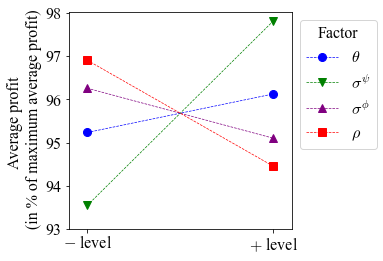

speed
[-0.00759553  0.00289901  0.0081456   0.0301824  -0.00910128  0.01015629
  0.00896192  0.0275857 ]
0.12213370235860375
volatility_purchase
[0.04003296 0.0299947  0.05577409 0.0572781  0.03512369 0.02621659
 0.0531869  0.043646  ]
1.9579122473447752e-05
volatility_sales
[-0.00320931 -0.01653952 -0.00471507 -0.00928223 -0.00811859 -0.02031762
 -0.00730226 -0.02291432]
0.003076470879827466
correlation
[-0.02189958 -0.01140504 -0.03193783 -0.00990103 -0.03522978 -0.0159722
 -0.04413687 -0.02551309]
0.0007076719021341771
speed volatility_purchase
0.009814642043116134
speed volatility_sales
0.0004963960594794592
speed correlation
0.008801586428458713
volatility_purchase speed
0.009814642043116134
volatility_purchase volatility_sales
-0.0031133330339953302
volatility_purchase correlation
-0.0033727795866952404
volatility_sales speed
0.0004963960594794592
volatility_sales volatility_purchase
-0.0031133330339953302
volatility_sales correlation
-0.005713557867864552
correlation speed
0.008

In [17]:
#get main effect of factor on average rewards for each problem

factors = ["speed", "volatility_purchase", "volatility_sales", "correlation"]

factor_symbols = {"speed": "$\\theta$", "correlation": "$\\rho$", "volatility_purchase": "$\sigma^{\psi}$", "volatility_sales": "$\sigma^{\phi}$"}

markers = {"speed": "o", "correlation": "s", "volatility_purchase": "v", "volatility_sales": "^"}

colors = {"speed": "blue", "correlation": "red", "volatility_purchase": "green", "volatility_sales": "purple"}
#other option: colors all black
#colors = {"speed": "black", "correlation": "black", "volatility_purchase": "black", "volatility_sales": "black"}

max_avg_reward = np.max([np.mean(normalized_rewards[pid][best_architecture[pid]]) for pid in problem_ids])

#instance with max average reward
max_avg_reward_pid = max(problem_ids, key=lambda pid: np.mean(normalized_rewards[pid][best_architecture[pid]]))
print(f"Problem instance with maximum average reward: {max_avg_reward_pid} with {np.mean(normalized_rewards[max_avg_reward_pid][best_architecture[max_avg_reward_pid]])} of maximum average reward")

factors_pid = {f: {} for f in factors}

print(problem_ids)
for pid in problem_ids:
    if pid[7] == "0":
        factors_pid["volatility_purchase"][pid] = 0
        factors_pid["volatility_sales"][pid] = 0
    elif pid[7] == "1":
        factors_pid["volatility_purchase"][pid] = 1
        factors_pid["volatility_sales"][pid] = 0
    elif pid[7] == "2":
        factors_pid["volatility_purchase"][pid] = 0
        factors_pid["volatility_sales"][pid] = 1
    elif pid[7] == "3":
        factors_pid["volatility_purchase"][pid] = 1
        factors_pid["volatility_sales"][pid] = 1
    
    if pid[8] == "1":
        factors_pid["correlation"][pid] = 0
    elif pid[8] == "2":
        factors_pid["correlation"][pid] = 1
    
    if pid[9] == "0":
        factors_pid["speed"][pid] = 0
    elif pid[9] == "2":
        factors_pid["speed"][pid] = 1

print(factors_pid)

#get average denormalized rewards for each factor level
mean_rewards_factor = {f: {0: [], 1: []} for f in factors}
for pid in problem_ids:
    for f in factors:
        factor = factors_pid[f][pid]
        mean_rewards_factor[f][factor].append(np.mean(normalized_rewards[pid][best_architecture[pid]])/max_avg_reward)

factor_pairs = {"speed": {0: [pid for pid in problem_ids if pid[9] == "0"], 1: [pid for pid in problem_ids if pid[9] == "2"]}, "correlation": {0: [pid for pid in problem_ids if pid[8] == "1"], 1: [pid for pid in problem_ids if pid[8] == "2"]}, "volatility_purchase": {0: [pid for pid in problem_ids if pid[7] == "0" or pid[7] == "2"], 1: [pid for pid in problem_ids if pid[7] == "1" or pid[7]=="3"]}, "volatility_sales": {0: [pid for pid in problem_ids if (pid[7] == "0" or pid[7] == "1")], 1: [pid for pid in problem_ids if (pid[7] == "2" or pid[7] == "3")]}}
print(factor_pairs)

mean_normalized_rewards = {pid: np.mean(normalized_rewards[pid][best_architecture[pid]])/max_avg_reward for pid in problem_ids}

#plot main effects of factors on average rewards for each problem by plotting the mean rewards for minus (0) and plus (1) level for each factor in the same figure

#change font style and size and math font
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams.update({'font.size': 16})
plt.rcParams['mathtext.fontset'] = 'cm' 

fig, ax = plt.subplots(1, 1, figsize=(4,4))

for f in factors:
   ax.plot([0,1], [np.mean(mean_rewards_factor[f][0]), np.mean(mean_rewards_factor[f][1])], label=f, marker=markers[f], markersize=8, linewidth=0.7, color=colors[f], linestyle="--")
#use symbols for factors in legend and place legend outside of plot

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, [factor_symbols[f] for f in factors], title="Factor", title_fontsize=16, loc="upper left", bbox_to_anchor=(1, 1))


ax.set_yticks([0.93, 0.94, 0.95, 0.96, 0.97, 0.98], [93, 94, 95, 96, 97, 98])
ax.set_xticks([0, 1], ["$-$ level", "$+$ level"])
ax.set_xlim(-0.1, 1.1)	
ax.set_ylabel("Average profit \n (in % of maximum average profit)")

plt.savefig(f"{os.getcwd()}/figures/main_effects_cheese.pdf", bbox_inches="tight")
plt.show()

#check significance of main effects of factors on average rewards for each problem using t-test
for f in factors:
    t, p = st.ttest_1samp(np.array([mean_normalized_rewards[pid] for pid in factor_pairs[f][1]]) - np.array([mean_normalized_rewards[pid] for pid in factor_pairs[f][0]]), 0)
    print(f)
    print(np.array([mean_normalized_rewards[pid] for pid in factor_pairs[f][1]]) - np.array([mean_normalized_rewards[pid] for pid in factor_pairs[f][0]]))
    print(p)

#calculate interaction effects of factors on average rewards for each problem
interaction_effects = {f1: {f2: 0 for f2 in factors} for f1 in factors}
for f1 in factors:
    for f2 in factors:
        if f1 == f2:
            continue
        interaction = 0
        for pid in problem_ids:
            if (factors_pid[f1][pid] == 0 and factors_pid[f2][pid] == 0) or (factors_pid[f1][pid] == 1 and factors_pid[f2][pid] == 1):
                interaction += mean_normalized_rewards[pid]
            else:
                interaction -= mean_normalized_rewards[pid]
        interaction_effects[f1][f2] = interaction/(len(problem_ids)/2)
        print(f1, f2)
        print(interaction_effects[f1][f2])




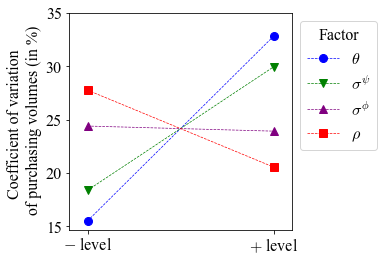

speed
[0.13002732 0.16367248 0.16407965 0.29819112 0.05758126 0.14827704
 0.16105493 0.25999732]
0.0003270827032984513
volatility_purchase
[0.11097379 0.05998876 0.14502611 0.1945074  0.0547414  0.04434608
 0.15821508 0.15606637]
0.0006849791701938554
volatility_sales
[ 0.06084428 -0.00216919 -0.01160179 -0.01756463  0.00461189 -0.01781186
  0.00158718 -0.05600566]
0.6918780134899959
correlation
[-0.06980416 -0.03615901 -0.12078919  0.01332228 -0.13281763 -0.04212185
 -0.14321295 -0.04427056]
0.007820167290252781


In [107]:
#get same figure for variability of purchasing volumes
actions = {pid: np.array(data[pid]["$SH$"]["responses"]) for pid in problem_ids}

#get variability of purchasing volumes for each problem
purchasing_volumes = {}

for pid in problem_ids:
    purchasing_volumes[pid] = actions[pid][:,0]

#get coefficient of variation of purchasing volumes for each problem
avg_purchasing_volumes = {pid: np.mean(purchasing_volumes[pid]) for pid in problem_ids}
cov_purchasing_volumes = {pid: np.std(purchasing_volumes[pid])/np.mean(purchasing_volumes[pid]) for pid in problem_ids}

#get average coefficient of variation of purchasing volumes for each factor level
mean_purchasing_cov_factor = {f: {0: [], 1: []} for f in factors}
avg_purchasing_volumes_factor = {f: {0: [], 1: []} for f in factors}
for pid in problem_ids:
    for f in factors:
        factor = factors_pid[f][pid]
        mean_purchasing_cov_factor[f][factor].append(cov_purchasing_volumes[pid])
        avg_purchasing_volumes_factor[f][factor].append(avg_purchasing_volumes[pid])

#plot main effects of factors on variability of purchasing volumes for each problem by plotting the mean rewards for minus (0) and plus (1) level for each factor in the same figure

fig, ax = plt.subplots(1, 1, figsize=(4,4))

for f in factors:
    ax.plot([0,1], [np.mean(mean_purchasing_cov_factor[f][0]), np.mean(mean_purchasing_cov_factor[f][1])], label=f, marker=markers[f], markersize=8, linewidth=0.7, color=colors[f], linestyle="--")
#use symbols for factors in legend and place legend outside of plot

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, [factor_symbols[f] for f in factors], title="Factor", title_fontsize=16, loc="upper left", bbox_to_anchor=(1, 1))

ax.set_xticks([0, 1], ["$-$ level", "$+$ level"])
ax.set_yticks([0.15, 0.2, 0.25, 0.3, 0.35], [15, 20, 25, 30, 35])
ax.set_xlim(-0.1, 1.1)
ax.set_ylabel("Coefficient of variation \n of purchasing volumes (in %)")

plt.savefig(f"{os.getcwd()}/figures/main_effects_purchasing_variability.pdf", bbox_inches="tight")
plt.show()

#calculate significance of main effects of factors on variability of purchasing volumes for each problem using t-test
for f in factors:
    t, p = st.ttest_1samp(np.array([cov_purchasing_volumes[pid] for pid in factor_pairs[f][1]]) - np.array([cov_purchasing_volumes[pid] for pid in factor_pairs[f][0]]), 0)
    print(f)
    print(np.array([cov_purchasing_volumes[pid] for pid in factor_pairs[f][1]]) - np.array([cov_purchasing_volumes[pid] for pid in factor_pairs[f][0]]) )
    print(p)    


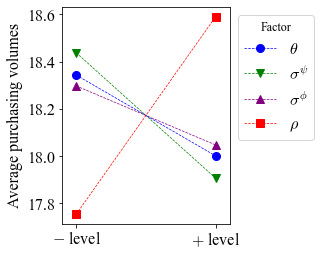

In [109]:
#get same figure for mean purchasing volumes
fig, ax = plt.subplots(1, 1, figsize=(3,4))

for f in factors:
    ax.plot([0,1], [np.mean(avg_purchasing_volumes_factor[f][0]), np.mean(avg_purchasing_volumes_factor[f][1])], label=f, marker=markers[f], markersize=8, linewidth=0.7, color=colors[f], linestyle="--")
#use symbols for factors in legend and place legend outside of plot
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, [factor_symbols[f] for f in factors], title="Factor", title_fontsize=12, loc="upper left", bbox_to_anchor=(1, 1))

ax.set_xticks([0, 1], ["$-$ level", "$+$ level"])
ax.set_xlim(-0.1, 1.1)
ax.set_ylabel("Average purchasing volumes")

plt.savefig(f"{os.getcwd()}/figures/main_effects_purchasing_volumes.pdf", bbox_inches="tight")
plt.show()


C:\Users\ga84cib\AppData\Local\Temp/ipykernel_37796/1402056536.py:10: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  average_issuance_age = {pid: {p: np.sum(np.mean(issuance[pid][:,i])*i for i in product_ages[p])/np.sum(np.mean(issuance[pid][:,i]) for i in product_ages[p]) for p in range(2)} for pid in problem_ids}


speed
0.023775008731106065
speed
1.2595670790501818e-05
volatility_purchase
0.035998467175621586
volatility_purchase
0.007114342324568988
volatility_sales
0.42660214370737715
volatility_sales
0.5137430914295988
correlation
0.7482430124382444
correlation
0.013384620882974624


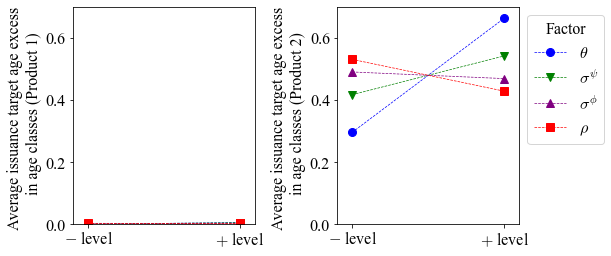

In [110]:
#create figure for main effects of factors on target age excess in issuance (one figure for each product)
#calculate target age excess
ages = [i for i in range(10)]
target_ages=[3,7]
evaporation = [0.04 for _ in range(4)] + [0.015 for _ in range(4)] + [0.01 for _ in range(2)]
evaporation_remains_per_age_class = np.array([np.prod([1-evaporation[a] for a in range(i+1)]) for i in ages])
issuance = {pid: actions[pid][:,3:] * evaporation_remains_per_age_class for pid in problem_ids}
production = {pid: actions[pid][:,1:3] for pid in problem_ids}
product_ages = {0: [3,4,5,6], 1: [7,8,9]}
average_issuance_age = {pid: {p: np.sum(np.mean(issuance[pid][:,i])*i for i in product_ages[p])/np.sum(np.mean(issuance[pid][:,i]) for i in product_ages[p]) for p in range(2)} for pid in problem_ids}
target_age_excess = {pid: {p: average_issuance_age[pid][p] - target_ages[p] for p in range(2)} for pid in problem_ids}

#get average target age excess for each factor level
mean_target_age_excess_factor = {f: {p: {0: [], 1: []} for p in range(2)} for f in factors}
for pid in problem_ids:
    for f in factors:
        factor = factors_pid[f][pid]
        mean_target_age_excess_factor[f][0][factor].append(target_age_excess[pid][0])
        mean_target_age_excess_factor[f][1][factor].append(target_age_excess[pid][1])

#plot main effects of factors on target age excess for each product by plotting the mean rewards for minus (0) and plus (1) level for each factor.
#Use two subfigures, one for product 0 and one for product 1
fig, ax = plt.subplots(1, 2, figsize=(8,4))

for f in factors:
    ax[0].plot([0,1], [np.mean(mean_target_age_excess_factor[f][0][0]), np.mean(mean_target_age_excess_factor[f][0][1])], label=f, marker=markers[f], markersize=8, linewidth=0.7, color=colors[f], linestyle="--")
    ax[1].plot([0,1], [np.mean(mean_target_age_excess_factor[f][1][0]), np.mean(mean_target_age_excess_factor[f][1][1])], label=f, marker=markers[f], markersize=8, linewidth=0.7, color=colors[f], linestyle="--")

#use symbols for factors in legend and place legend outside of plot
handles, _ = ax[0].get_legend_handles_labels()
ax[1].legend(handles, [factor_symbols[f] for f in factors], title="Factor", title_fontsize=16, loc="upper left", bbox_to_anchor=(1, 1))

for i in range(2):
    ax[i].set_xticks([0, 1], ["$-$ level", "$+$ level"])
    ax[i].set_xlim(-0.1, 1.1)
    ax[i].set_ylim(0,0.7)
    ax[i].set_ylabel("Average issuance target age excess \n in age classes (Product {})".format(i+1))

#increase space between subfigures
plt.subplots_adjust(wspace=0.45)
plt.savefig(f"{os.getcwd()}/figures/main_effects_target_age_excess.pdf", bbox_inches="tight")

#calculate significance of main effects of factors on target age excess for each product using t-test
for f in factors:
    for p in range(2):
        t, p = st.ttest_1samp(np.array([target_age_excess[pid][p] for pid in factor_pairs[f][1]]) - np.array([target_age_excess[pid][p] for pid in factor_pairs[f][0]]), 0)
        print(f)
        print(p)

speed
0.15963481092994947
speed
0.0976668477934113
volatility_purchase
0.004250691634252014
volatility_purchase
0.9972099371276893
volatility_sales
0.2029083766619478
volatility_sales
0.4692422232072845
correlation
0.001877225951621798
correlation
0.9478078544724886


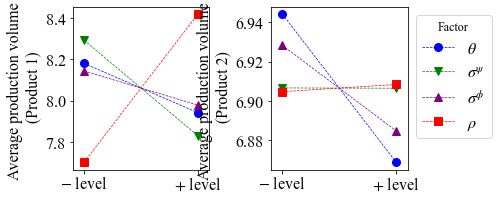

In [58]:
#calculate main effects of factors on average production volumes for each product
#get average production volumes for each problem
avg_production = {pid: {p: np.mean(production[pid][:,p]) for p in range(2)} for pid in problem_ids}

#get average production volumes for each factor level
mean_production_factor = {f: {p: {0: [], 1: []} for p in range(2)} for f in factors}
for pid in problem_ids:
    for f in factors:
        factor = factors_pid[f][pid]
        for p in range(2):
            mean_production_factor[f][p][factor].append(avg_production[pid][p])

#plot main effects of factors on average production volumes for each product by plotting the mean rewards for minus (0) and plus (1) level for each factor.
#Use two subfigures, one for product 0 and one for product 1
fig, ax = plt.subplots(1, 2, figsize=(6,3))

for f in factors:
    for p in range(2):
        ax[p].plot([0,1], [np.mean(mean_production_factor[f][p][0]), np.mean(mean_production_factor[f][p][1])], label=f, marker=markers[f], markersize=8, linewidth=0.7, color=colors[f], linestyle="--")

#use symbols for factors in legend and place legend outside of plot
handles, _ = ax[0].get_legend_handles_labels()
ax[1].legend(handles, [factor_symbols[f] for f in factors], title="Factor", title_fontsize=12, loc="upper left", bbox_to_anchor=(1, 1))

for i in range(2):
    ax[i].set_xticks([0, 1], ["$-$ level", "$+$ level"])
    ax[i].set_xlim(-0.1, 1.1)
    ax[i].set_ylabel("Average production volume \n (Product {})".format(i+1))

#increase space between subfigures
plt.subplots_adjust(wspace=0.45)
plt.savefig(f"{os.getcwd()}/figures/main_effects_production.pdf", bbox_inches="tight")

#calculate significance of main effects of factors on average production volumes for each product using t-test
for f in factors:
    for p in range(2):
        t, p = st.ttest_1samp(np.array([avg_production[pid][p] for pid in factor_pairs[f][1]]) - np.array([avg_production[pid][p] for pid in factor_pairs[f][0]]), 0)
        print(f)
        print(p)
        




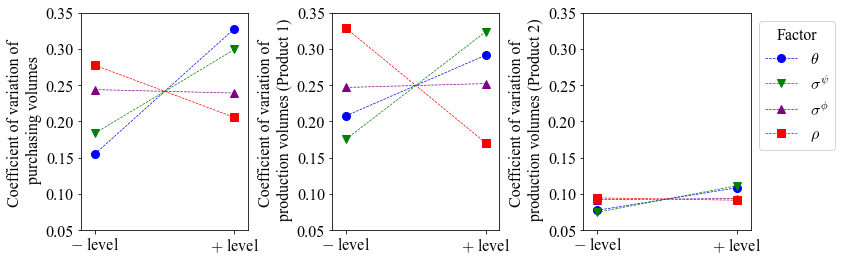

In [112]:
#calculate main effects of factors on variability of production volumes for each product
#get variability of production volumes for each problem
cov_production_volumes = {pid: {p: np.std(production[pid][:,p])/np.mean(production[pid][:,p]) for p in range(2)} for pid in problem_ids}

#get average coefficient of variation of production volumes for each factor level
mean_production_cov_factor = {f: {p: {0: [], 1: []} for p in range(2)} for f in factors}
for pid in problem_ids:
    for f in factors:
        factor = factors_pid[f][pid]
        for p in range(2):
            mean_production_cov_factor[f][p][factor].append(cov_production_volumes[pid][p])

#plot main effects of factors on variability of production volumes for each product by plotting the mean rewards for minus (0) and plus (1) level for each factor.
# Use two subfigures, one for product 0 and one for product 1
# Use the same symbols and colors for factors as in the previous figure
# Use the same symbols for factors in the legend and place the legend outside of the plot
fig, ax = plt.subplots(1, 3, figsize=(12,4))

#plot purchasing volumes variability
for f in factors:
    ax[0].plot([0,1], [np.mean(mean_purchasing_cov_factor[f][0]), np.mean(mean_purchasing_cov_factor[f][1])], label=f, marker=markers[f], markersize=8, linewidth=0.7, color=colors[f], linestyle="--")

for f in factors:
    for p in range(2):
        ax[p+1].plot([0,1], [np.mean(mean_production_cov_factor[f][p][0]), np.mean(mean_production_cov_factor[f][p][1])], label=f, marker=markers[f], markersize=8, linewidth=0.7, color=colors[f], linestyle="--")

#use symbols for factors in legend and place legend outside of plot
handles, _ = ax[0].get_legend_handles_labels()
ax[2].legend(handles, [factor_symbols[f] for f in factors], title="Factor", title_fontsize=16, loc="upper left", bbox_to_anchor=(1, 1))

for i in range(3):
    ax[i].set_xticks([0, 1], ["$-$ level", "$+$ level"])
    ax[i].set_xlim(-0.1, 1.1)
    ax[i].set_ylim(0.05, 0.35)
    if i > 0:
        ax[i].set_ylabel("Coefficient of variation of \n production volumes (Product {})".format(i))
    else:
        ax[i].set_ylabel("Coefficient of variation of \n purchasing volumes")

#increase space between subfigures
plt.subplots_adjust(wspace=0.5)
plt.savefig(f"{os.getcwd()}/figures/main_effects_variability.pdf", bbox_inches="tight")
plt.show()


#    





['$\\psi$', '$\\phi_{w1}$', '$\\phi_{w2}$', '$v_1$', '$v_2$', '$v_3$', '$v_4$', '$v_5$', '$v_6$', '$v_7$', '$v_8$', '$v_9$', '$v_10$']
cheese_020


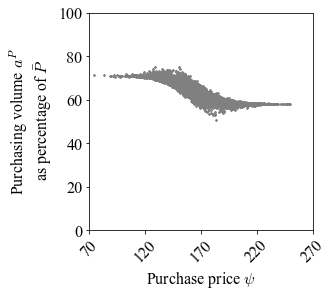

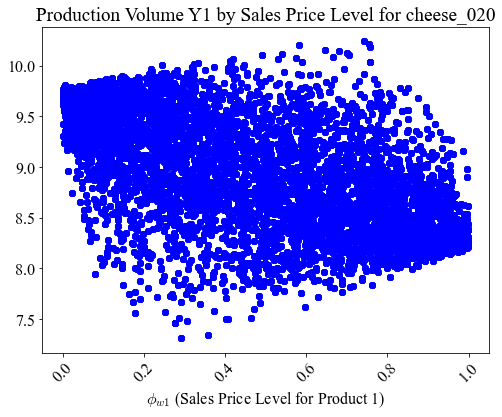

In [41]:
import pandas as pd
#import seaborn as sns

#check correlation between state features and actions
feature_names = ["$\psi$", "$\phi_{w1}$", "$\phi_{w2}$"] + [f"$v_{i}$" for i in range(1, 11)]
# feature_names.append("margin")
# feature_names.append("margin_young")
# feature_names.append("margin_old")
# feature_names.append("inventory")
# feature_names.append("young_inventory")
print(feature_names)
action_names = ["P"] + [f"Y_{i}" for i in range(1,3)] + [f"X_{i}" for i in range(1, 11)]

#calculate and save (json) correlation matrix for each problem
corr_matrix = {}
for pid in ["cheese_020"]:
    print(pid)
    #pid = "cheese_010"

    #get correlation of state features and purchasing_action (the first action)
    features = np.array(data[pid]["$SH$"]["features"])
    actions = np.array(data[pid]["$SH$"]["responses"])

    #add a feature for overall margin
    nProducts = 2
    price_means = [170,250,350]
    if pid[9] == "0":
        speed = [0.05,0.05,0.05]
    elif pid[9] == "1":
        speed = [0.1,0.1,0.1]
    elif pid[9] == "2":
        speed = [0.25,0.25,0.25]
    elif pid[9] == "3":
        speed = [1.0,1.0,1.0] 
    vol_multipliers = {"0": [1,1,1], "1":[2,1,1], "2":[1,2,2], "3":[2,2,2]}
    if pid[9] == "0":
        vol = [np.sqrt(975*vol_multipliers[pid[7]][i]/19.0) for i in range(nProducts+1)]
    elif pid[9] == "1":
        vol = [np.sqrt(1900*vol_multipliers[pid[7]][i]/19.0) for i in range(nProducts+1)]
    elif pid[9] == "2":
        vol = [np.sqrt(4375*vol_multipliers[pid[7]][i]/19.0) for i in range(nProducts+1)]
    elif pid[9] == "3":
        vol = [np.sqrt(10000*vol_multipliers[pid[7]][i]/19.0) for i in range(nProducts+1)]

    price_covs = [np.sqrt((vol[i]**2)/(1-(1-speed[i])**2))/price_means[i] for i in range(nProducts+1)]
    price_distributions = [st.norm(loc=price_means[i], scale=price_covs[i]*price_means[i]) for i in range(nProducts+1)]

    #price_distributions = [st.truncnorm(loc=price_means[i], scale=price_covs[i]*price_means[i], a=0.00001, b=0.99999) for i in range(nProducts+1)]

    # margins = np.array([sum([price_distributions[i+1].ppf(features[j,i+1]) for i in range(nProducts)]) - price_distributions[0].ppf(features[j,0]) for j in range(len(features))])
    # margin_young = np.array([sum([price_distributions[i+1].ppf(features[j,i+1]) for i in range(nProducts-1)]) - price_distributions[0].ppf(features[j,0]) for j in range(len(features))])
    # margin_old = np.array([price_distributions[2].ppf(features[j,2]) - price_distributions[0].ppf(features[j,0]) for j in range(len(features))])

    # total_inventory = np.array([sum(features[j,3:]) for j in range(len(features))])
    # young_inventory = np.array([sum(features[j,3:6]) for j in range(len(features))])
                               

    # #append margins & inventory to features
    # features = np.hstack((features, margins.reshape(-1,1)))
    # features = np.hstack((features, margin_young.reshape(-1,1)))
    # features = np.hstack((features, margin_old.reshape(-1,1)))

    # features = np.hstack((features, total_inventory.reshape(-1,1)))
    # features = np.hstack((features, young_inventory.reshape(-1,1)))
    
    frame = np.hstack((features, actions))

    columns = feature_names + action_names

    df = pd.DataFrame(frame, columns=columns)

    #add a column for the real price instead of cdf
    df["$\psi_real$"] = price_distributions[0].ppf(df["$\psi$"])  

    plt.rcParams["font.family"] = "Times New Roman"
    plt.rcParams.update({'font.size': 16})
    plt.rcParams['mathtext.fontset'] = 'cm'
    #show heatmap of purchasing volumes (action P) by price level (feature psi) - use matplotlib
    plt.figure(figsize=(4, 4))
    
    plt.scatter(df["$\psi_real$"], df["P"], alpha=0.5, color='grey', s=1)
    plt.xticks(rotation=45)
    #on x-axis show real price instead of cdf
    #plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1], [round(price_distributions[0].ppf(0.001), ndigits=1), round(price_distributions[0].ppf(0.2), ndigits=1), round(price_distributions[0].ppf(0.4), ndigits=1), round(price_distributions[0].ppf(0.6), ndigits=1), round(price_distributions[0].ppf(0.8), ndigits=1), round(price_distributions[0].ppf(0.999), ndigits=1)])
    plt.xticks([70, 120, 170, 220, 270])
    plt.xlim(70,270)

    plt.xlabel("Purchase price $\psi$")
    plt.ylabel("Purchasing volume $a^P$ \n as percentage of $\\bar{P}$")
    plt.yticks([0,6,12,18,24,30], [0,20, 40, 60, 80, 100])
    
    plt.savefig(f"figures/purchasing_volume_by_price_{pid}.pdf", bbox_inches='tight', pad_inches=0.1)
    #show another heatmap of production volumes Y1 by sales price level phi_w1

    plt.figure(figsize=(8, 6))
    plt.scatter(df["$\phi_{w1}$"], df["Y_1"], alpha=0.5, color='blue')
    plt.xticks(rotation=45)
    plt.title(f"Production Volume Y1 by Sales Price Level for {pid}")
    plt.xlabel("$\phi_{w1}$ (Sales Price Level for Product 1)")



    #calculate correlation matrix
    # corr_matrix[pid] = df.corr()

    

    #extract correlation of state features with purchasing action
    #state_purchasing_corr = corr_matrix["P"][:-13]

    #print(state_purchasing_corr)

    #get correlation of prices
    #price_corr = corr_matrix[:3][:3]

    #print(price_corr)

#save correlation matrix to json file (json does not work with numpy arrays)
# for pid in problem_ids:
#     print(pid)
#     corr_matrix[pid] = corr_matrix[pid].to_dict()
    

# with open("cheese/corr_matrix.json", "w") as f:
#     json.dump(corr_matrix, f)